This code plots the differences between the max elevation output for Holland and OWI on the 31k mesh.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.basemap import Basemap
import scipy.io
from scipy.interpolate import griddata

In [20]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX to render text
    "font.family": "serif",  # Use serif font (like LaTeX)
    "font.serif": ["Computer Modern Roman"],  # Specific LaTeX font
    "font.size": 12,  # Font size
})


In [2]:
# Read in mesh
mesh = pd.read_csv("data/inputs/meshes/30kfort14.txt", delimiter=r'\s+', header=None, usecols=[1,2],nrows=31435, names=['Lat','Lon'])


In [3]:
# Load in maxele files

def load_maxele63(file_path, n_rows):
    """
    Reads a .txt file and returns a column of representing the max elevation at each node
    in a pandas dataframe. 
    
    Parameters:
        file_path (str): Path to the .txt file.
        
    Returns:
        pd.DataFrame: DataFrame containing the second column of numbers.
    """
    # Read the file, skip the first three rows, and select only the second column
    df = pd.read_csv(file_path, delimiter=r'\s+', skiprows=3, header=None, usecols=[1],nrows=n_rows)
    
    return df



In [4]:
# Load in OWI and HOL maxele.63 files

OWI_maxele = load_maxele63("OWI_data/30k_mesh/OWI_maxele63.txt", n_rows = 31435) 
HOL_maxele = load_maxele63("Holland_data/HOL_maxele63.txt", n_rows = 31435)

In [5]:
# Analyze diffs, filter out unnecessary values

difference = HOL_maxele - OWI_maxele
df_sorted = difference.sort_values(by=difference.columns[0], ascending=True) # so we can see what the biggest diffs are
df_filtered = difference[difference.iloc[:, 0].abs() <= 9999] # removes indices with 9999

In [6]:
# Dropping these values from the mesh as well

# Get the indices of the rows that are kept in df_filtered
kept_indices = df_filtered.index

# Drop the same rows in mesh
mesh_cleaned = mesh.loc[kept_indices]


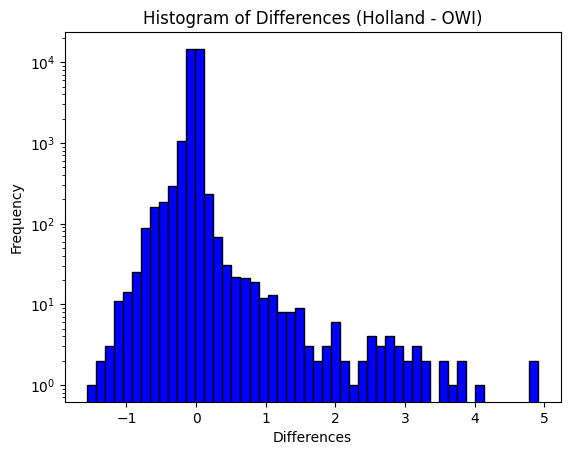

In [7]:
# histogram


data = df_filtered.iloc[:, 0]
bins = 50


plt.figure()
plt.hist(data, bins=50, color='b', edgecolor='k')
plt.yscale('log') 
plt.xlabel('Differences')
plt.ylabel('Frequency')
plt.title('Histogram of Differences (Holland - OWI)')
plt.show()


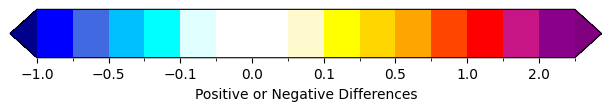

In [8]:
# Defining the colorbar to be used
fig, ax = plt.subplots(figsize=(6, 1), layout='constrained')

# Define the custom colormap
cmap = mpl.colors.ListedColormap(['blue','royalblue', 'deepskyblue', 'cyan', 'lightcyan', 'white', 
                                  'white', 'lemonchiffon', 'yellow', 
                                  'gold','orange', 'orangered', 'red', 'mediumvioletred', 'darkmagenta'])
cmap = cmap.with_extremes(over='purple', under='darkblue')  # Set colors for values outside the bounds

# Define the boundaries for the colormap
bounds = [-1, -0.75, -0.5, -0.25, -0.10, -0.05, 0.0, 0.05, 0.10, 0.25, 0.5, 0.75, 1, 1.5, 2, 2.5]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)  # Normalize the colormap based on the bounds

# Create the colorbar
fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=ax, orientation='horizontal',
    extend='both',  # Extend the colorbar to show 'over' and 'under' colors
    label='Positive or Negative Differences',
)

plt.show()

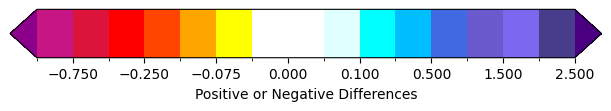

In [ ]:
# Defining the colorbar to be used
fig, ax = plt.subplots(figsize=(6, 1), layout='constrained')

# Define the custom colormap
cmap = mpl.colors.ListedColormap(['mediumvioletred','crimson','red','orangered','orange','yellow', 
                                   'white', 'white',
                                   'lightcyan','cyan','deepskyblue','royalblue','slateblue','mediumslateblue','darkslateblue'])
cmap = cmap.with_extremes(over='indigo', under='darkmagenta')  # Set colors for values outside the bounds

# Define the boundaries for the colormap
bounds = [-1, -0.75, -0.5, -0.25, -0.10, -0.075, -0.05, 0.0, 0.05, 0.10, 0.25, 0.5, 1, 1.5, 2, 2.5]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)  # Normalize the colormap based on the bounds

# Create the colorbar
fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=ax, orientation='horizontal',
    extend='both',  # Extend the colorbar to show 'over' and 'under' colors
    label='Positive or Negative Differences',
)

plt.show()

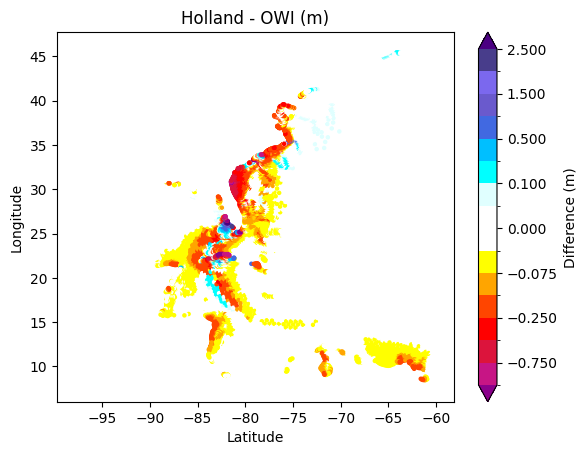

In [22]:
data = df_filtered.iloc[:, 0]  

# Create the scatter plot
plt.figure()
scatter = plt.scatter(mesh_cleaned.iloc[:, 0], mesh_cleaned.iloc[:, 1], c=data, cmap=cmap, norm=norm, 
                      s=5, alpha=1)

# Add color bar
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Difference (m)')
plt.title('Holland - OWI (m)')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [ ]:
plt.figure(figsize=(11, 8))
m = Basemap(llcrnrlon=-99, llcrnrlat=15, urcrnrlon=-60, urcrnrlat=45)
m.etopo()
# m.drawmapboundary(fill_color='aqua')
# m.fillcontinents(color='coral', lake_color='aqua')
scatter = m.scatter(mesh_cleaned.iloc[:,0], mesh_cleaned.iloc[:,1], c=normalized_diffs, cmap='gist_ncar', s=10, 
                      alpha = 0.8)
cbar = plt.colorbar(scatter)
# contour = m.contourf(mesh_cleaned.iloc[:,0], mesh_cleaned.iloc[:,1], normalized_diffs, cmap='gist_ncar', alpha = 0.8)
# cbar = m.colorbar(contour)
cbar.set_label('Transformed Size of OWI - Holland')

# lons = mesh_cleaned.iloc[:,0].values
# lats = mesh_cleaned.iloc[:,1].values
# values = normalized_diffs.values

# print(lats)
# grid_lons, grid_lats = np.mgrid[-99:-60:100j, 15:45:100j]

# grid_values = griddata((lons, lats), values, (grid_lons, grid_lats), method='cubic')
# contour = plt.contourf(grid_lons, grid_lats, grid_values, cmap='viridis', alpha=0.5)
